# Crime Linkage: Homicide Data EDA

Aiden Thakur, Evan Blem

## Problem Statement

Identifying whether separate homicide incidents may be part of the same crime series is one of the hardest problems in criminal investigation. Investigators have to look at dozens of factors — where the crime happened, when it happened, how it was carried out, and who the victim was — and try to spot patterns across cases that could indicate a common source. Most of this work is done manually by experienced detectives, but the sheer volume of cases in large cities makes it easy for connections to slip through the cracks, especially when crimes cross jurisdictional boundaries.

Our goal is to build a probabilistic decision-support tool that helps structure this problem. The system should highlight similarities between incidents across spatial, temporal, behavioral, and victim-level features without ever claiming to identify a suspect or produce a deterministic answer. It is a tool to help investigators focus their attention, not replace their judgment.

This notebook explores the Crime Open Database (CODE) homicide dataset to understand what features are available, what the data looks like, where the gaps are, and what relationships exist between variables. This will inform how we design the similarity metrics and clustering pipeline later on.

Data source for the homicide records:

https://osf.io/zyaqn/ — Crime Open Database (CODE) maintained by Dr. Matthew Ashby. The data is compiled from NIBRS (National Incident-Based Reporting System) records across major US cities.

The project proposal and background research draws on Crime Pattern Theory and behavioral consistency principles from the crime linkage literature.

Modules used and why:
- **Pandas**: Loading, cleaning and working with the data
- **Seaborn**: Statistical plots and heatmaps
- **Matplotlib**: General plotting and figure layout
- **Numpy**: Math operations and array handling
- **Scipy**: For distance calculations and kernel density estimation
- **Warnings**: Suppressing unnecessary warning messages during plotting

In [109]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings("ignore")

## Loading the Data

This dataset was pulled from the OSF Crime Open Database. It contains homicide offense records from NIBRS-reporting cities across the US. Each row is a single homicide incident with information about where and when it happened, what type of location it occurred at, and some geographic identifiers.

Taking a first look at the columns and their data types. I also want to check how many rows and cities we are working with.

In [111]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36699 entries, 0 to 36698
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   uid                36699 non-null  int64  
 1   city_name          36699 non-null  str    
 2   offense_code       36699 non-null  str    
 3   offense_type       36699 non-null  str    
 4   offense_group      36699 non-null  str    
 5   offense_against    36699 non-null  str    
 6   date_single        36699 non-null  str    
 7   longitude          36699 non-null  float64
 8   latitude           36699 non-null  float64
 9   location_type      18804 non-null  str    
 10  location_category  19292 non-null  str    
 11  census_block       36699 non-null  int64  
 12  date_start         6180 non-null   str    
 13  date_end           4396 non-null   str    
dtypes: float64(2), int64(2), str(10)
memory usage: 3.9 MB


In [112]:
print(f"Total incidents: {len(df):,}")
print(f"Number of cities: {df['city_name'].nunique()}")
print(f"Date range: {df['date_single'].min()} to {df['date_single'].max()}")

Total incidents: 36,699
Number of cities: 20
Date range: 2007-01-01 00:15 to 2022-12-31 23:16


We have 36,699 homicide incidents across 20 US cities from 2007 through 2022. The columns break down into a few groups:
- **Where**: longitude, latitude, census_block, location_type, location_category
- **When**: date_single, date_start, date_end
- **What**: offense_code, offense_type, offense_group, offense_against
- **ID**: uid, city_name

Right away I notice there is no victim-level information (age, sex, race) in this dataset. That's something we will need to get from another source later on. For now lets work with what we have.

## Checking for Missing Values

Before anything else I want to see where the gaps are in the data. Missing values will directly affect which features we can reliably use when comparing incidents.

In [113]:
df.isna().sum()

uid                      0
city_name                0
offense_code             0
offense_type             0
offense_group            0
offense_against          0
date_single              0
longitude                0
latitude                 0
location_type        17895
location_category    17407
census_block             0
date_start           30519
date_end             32303
dtype: int64

In [114]:
# Percentage missing for each column
missing_pct = (df.isna().sum() / len(df) * 100).round(1)
missing_pct[missing_pct > 0]

location_type        48.8
location_category    47.4
date_start           83.2
date_end             88.0
dtype: float64

The spatial columns (longitude, latitude) and the date_single column are fully populated which is great since those are our most important features. However we have some significant gaps:

- **location_type** is missing about 49% of its values
- **location_category** is missing about 47%
- **date_end** is missing 88% and **date_start** is missing 83%

The date_start and date_end columns represent a time window when the exact time of death is uncertain. Most incidents just have a single timestamp (date_single) which makes sense since that is the more commonly recorded field. The location fields being half missing is more concerning since those are the only behavioral/MO-type features we have in this dataset.

I want to see if the missing values are spread evenly or if certain cities just dont report certain fields. This matters because if missingness is city-dependent then its really a reporting issue, not a data quality issue with individual records.

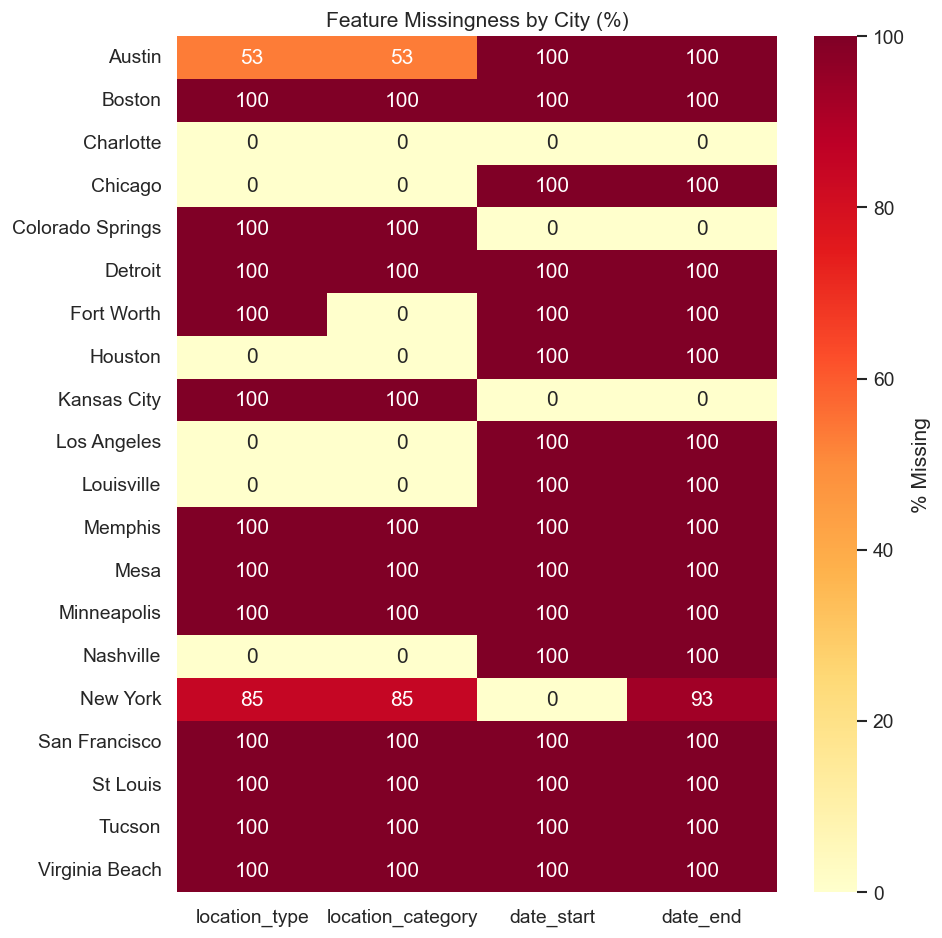

In [115]:
miss_cols = ['location_type', 'location_category', 'date_start', 'date_end']
miss_by_city = df.groupby('city_name')[miss_cols].apply(
    lambda g: g.isnull().mean() * 100
).round(1)

plt.figure(figsize=(8, 8))
sns.heatmap(miss_by_city, annot=True, fmt='.0f', cmap='YlOrRd',
            cbar_kws={'label': '% Missing'})
plt.title('Feature Missingness by City (%)')
plt.ylabel('')
plt.tight_layout()
plt.show()

This confirms it — missingness is very city-dependent. Some cities like Chicago, Detroit and Memphis have nearly 100% missing location data, while cities like Austin, Nashville and Virginia Beach report it almost completely. The date_start and date_end fields follow a similar pattern.

This tells us that when we build our similarity metrics, we need to handle missing categorical data carefully. We cant just drop rows with missing location info because we would lose entire cities. Instead we will need some kind of flag or adjusted weighting when one or both incidents in a comparison are missing a feature.

Checking for duplicated rows:

In [116]:
print(f"Duplicated rows: {df.duplicated().sum()}")

Duplicated rows: 0


Now lets fix the data types. The date columns need to be converted to datetime objects so we can work with them properly. I also want to parse out some useful time components.

In [117]:
df['date_single'] = pd.to_datetime(df['date_single'], format='mixed')
df['date_start'] = pd.to_datetime(df['date_start'], format='mixed', errors='coerce')
df['date_end'] = pd.to_datetime(df['date_end'], format='mixed', errors='coerce')

df['year'] = df['date_single'].dt.year
df['month'] = df['date_single'].dt.month
df['dow'] = df['date_single'].dt.day_name()
df['hour'] = df['date_single'].dt.hour

df.dtypes

uid                           int64
city_name                       str
offense_code                    str
offense_type                    str
offense_group                   str
offense_against                 str
date_single          datetime64[us]
longitude                   float64
latitude                    float64
location_type                   str
location_category               str
census_block                  int64
date_start           datetime64[us]
date_end             datetime64[us]
year                          int32
month                         int32
dow                             str
hour                          int32
dtype: object

One thing I want to check is how many timestamps fall exactly at midnight (00:00). In crime data, midnight-exact times often mean the exact time was unknown and got recorded as the default. This is important because if we are measuring temporal distance between incidents, we need to know which timestamps are reliable.

In [118]:
midnight = (df['date_single'].dt.hour == 0) & (df['date_single'].dt.minute == 0)
print(f"Midnight-exact timestamps: {midnight.sum():,} ({midnight.mean()*100:.1f}%)")

Midnight-exact timestamps: 2,640 (7.2%)


About 7% of records have midnight-exact timestamps. Thats not a huge portion but its enough that we should flag these and keep that in mind when computing temporal distances. A timestamp that says 00:00 could be off by hours from the real event time.

## Exploring the Data

### Cities

Lets start by seeing how the incidents are distributed across cities.

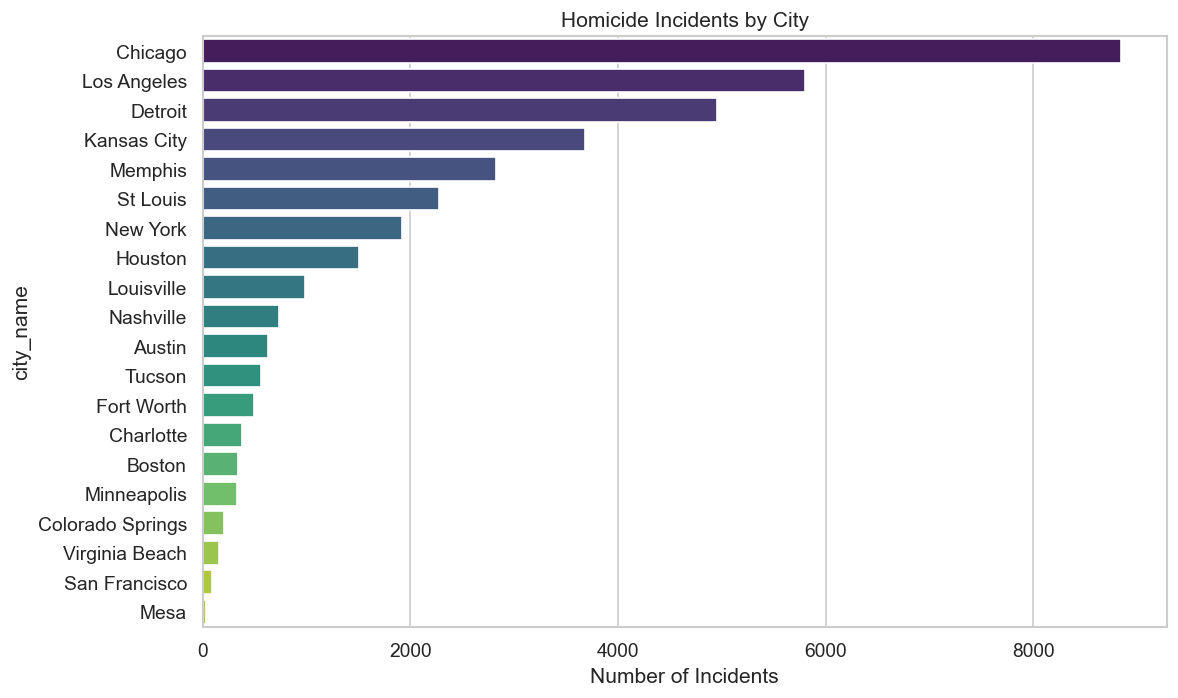

In [119]:
city_counts = df['city_name'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=city_counts.values, y=city_counts.index, palette='viridis')
plt.xlabel('Number of Incidents')
plt.title('Homicide Incidents by City')
plt.tight_layout()
plt.show()

Chicago dominates with nearly 9,000 incidents which is about 24% of the entire dataset. Los Angeles and Detroit are next with around 5,000 each. On the other end, Mesa only has 26 incidents and San Francisco has 90. This imbalance is something to keep in mind — if we train our model on this data as-is, the patterns in Chicago will heavily influence the results.

Lets also look at the split between murder and negligent manslaughter:

In [120]:
print(df['offense_type'].value_counts())
print(f"\nMurder makes up {(df['offense_type']=='murder and nonnegligent manslaughter').mean()*100:.1f}% of the data")

offense_type
murder and nonnegligent manslaughter    35981
negligent manslaughter                    718
Name: count, dtype: int64

Murder makes up 98.0% of the data


98% of the data is murder and nonnegligent manslaughter with only about 700 cases of negligent manslaughter. For our linkage purposes, negligent manslaughter is less likely to be part of a serial pattern so this distribution actually works in our favor — the vast majority of records are the type of crime we care about.

### Spatial Features

Geography is one of the most important features for crime linkage. Lets look at where these incidents are spread across the country.

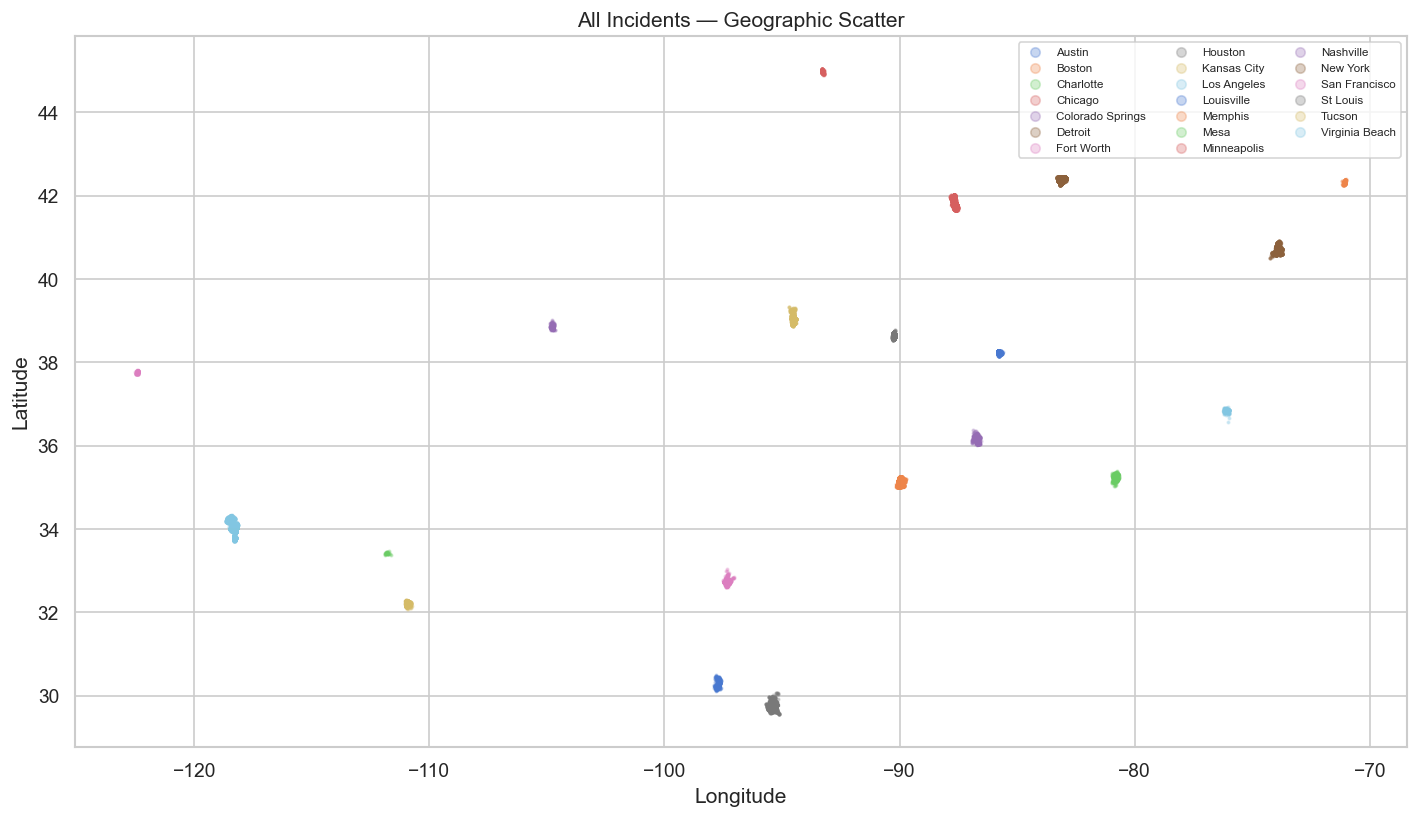

In [121]:
plt.figure(figsize=(12, 7))
for city, grp in df.groupby('city_name'):
    plt.scatter(grp['longitude'], grp['latitude'], s=2, alpha=0.3, label=city)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('All Incidents — Geographic Scatter')
plt.legend(fontsize=7, ncol=3, markerscale=4, bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

Each cluster of points is a city. You can clearly see the geographic separation — cities on the east coast vs midwest vs west coast. Within each city the incidents are spread across the urban area. Lets zoom into a few individual cities to see the spatial patterns up close.

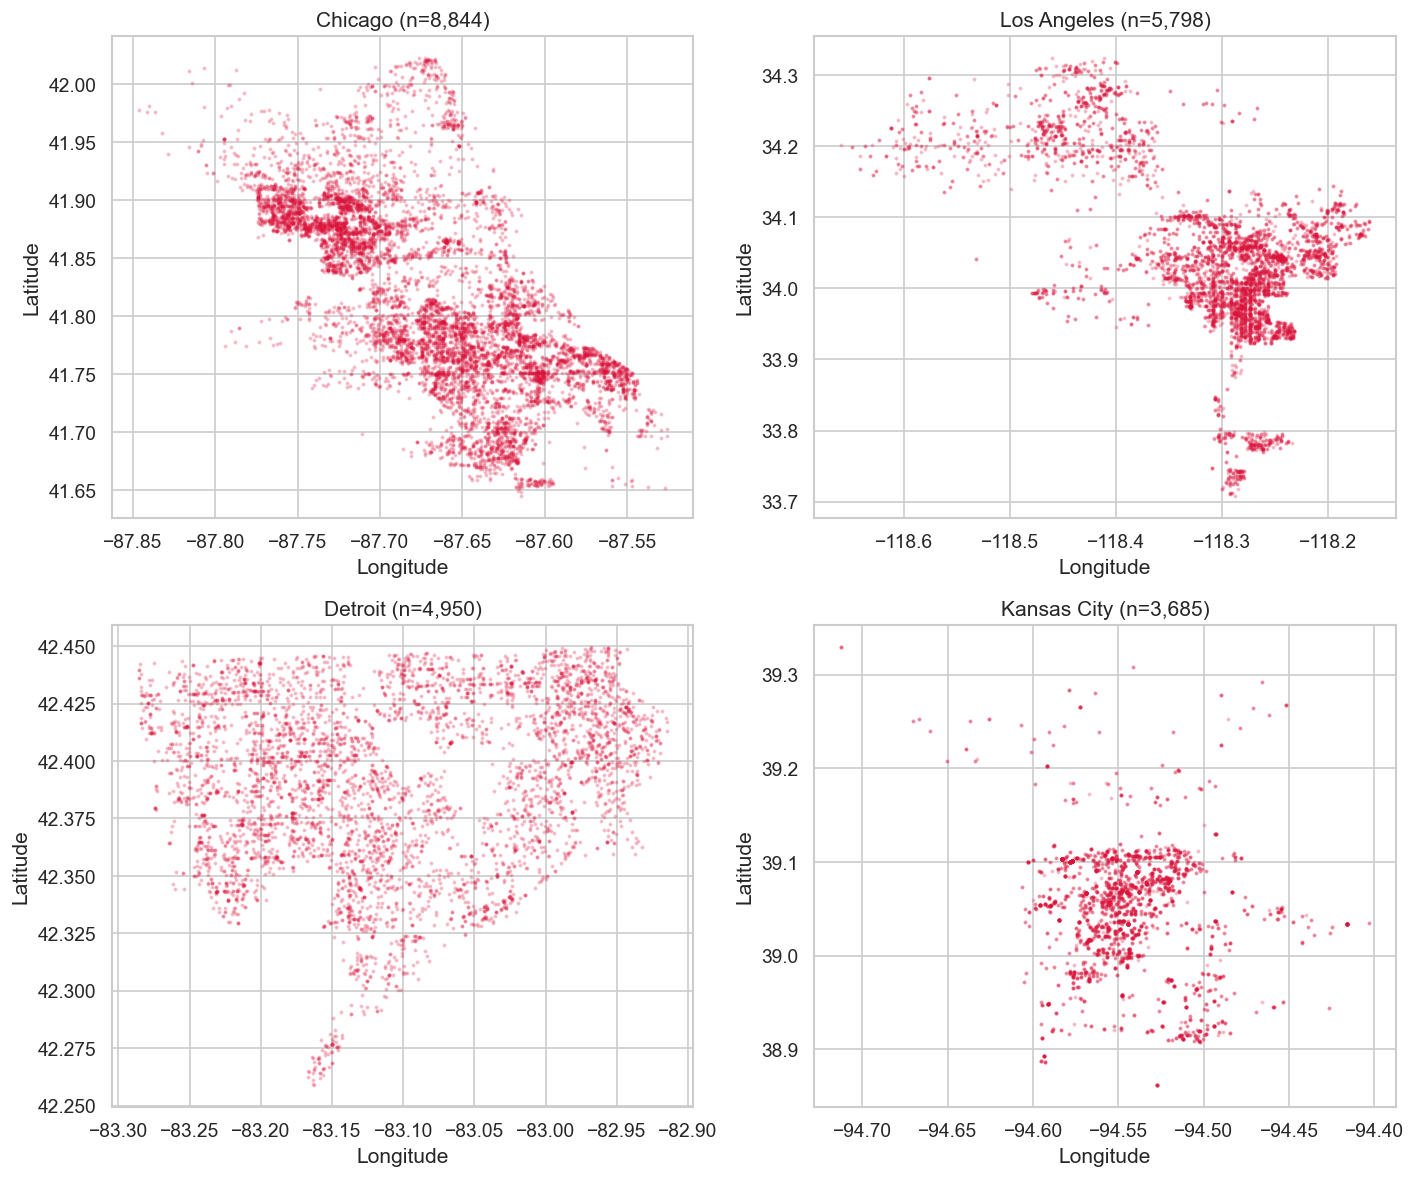

In [122]:
top4 = df['city_name'].value_counts().head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, city in zip(axes.flat, top4):
    sub = df[df['city_name'] == city]
    ax.scatter(sub['longitude'], sub['latitude'], s=2, alpha=0.2, color='crimson')
    ax.set_title(f'{city} (n={len(sub):,})')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

The spatial spread varies a lot by city. Los Angeles covers a much wider geographic area than Detroit or Kansas City. This means that raw geographic distance between two incidents will mean very different things depending on the city — 10 km in Detroit covers a much larger proportion of the city than 10 km in LA.

Lets quantify this by looking at the coordinate ranges:

In [123]:
spatial_stats = df.groupby('city_name').agg(
    n=('uid', 'count'),
    lon_range=('longitude', lambda x: x.max() - x.min()),
    lat_range=('latitude', lambda x: x.max() - x.min())
).sort_values('n', ascending=False).round(4)

spatial_stats

,n,lon_range,lat_range
city_name,,,
Chicago,8844,0.3207,0.3777
Los Angeles,5798,0.4985,0.6159
Detroit,4950,0.3711,0.1906
Kansas City,3685,0.3097,0.4673
Memphis,2823,0.4140,0.2580
St Louis,2272,0.1369,0.2279
New York,1916,0.5189,0.3914
Houston,1507,0.5817,0.5196
Louisville,985,0.2150,0.1289


The longitude and latitude ranges confirm what we saw visually. Los Angeles has about 0.7 degrees of longitude spread while a city like Virginia Beach is more compact. When we normalize spatial distances later, we will need to account for these city-level scale differences.

### Temporal Features

Now lets look at the time dimension. Understanding when homicides happen can reveal patterns that are useful for linkage — serial offenders often operate on certain schedules or during certain conditions.

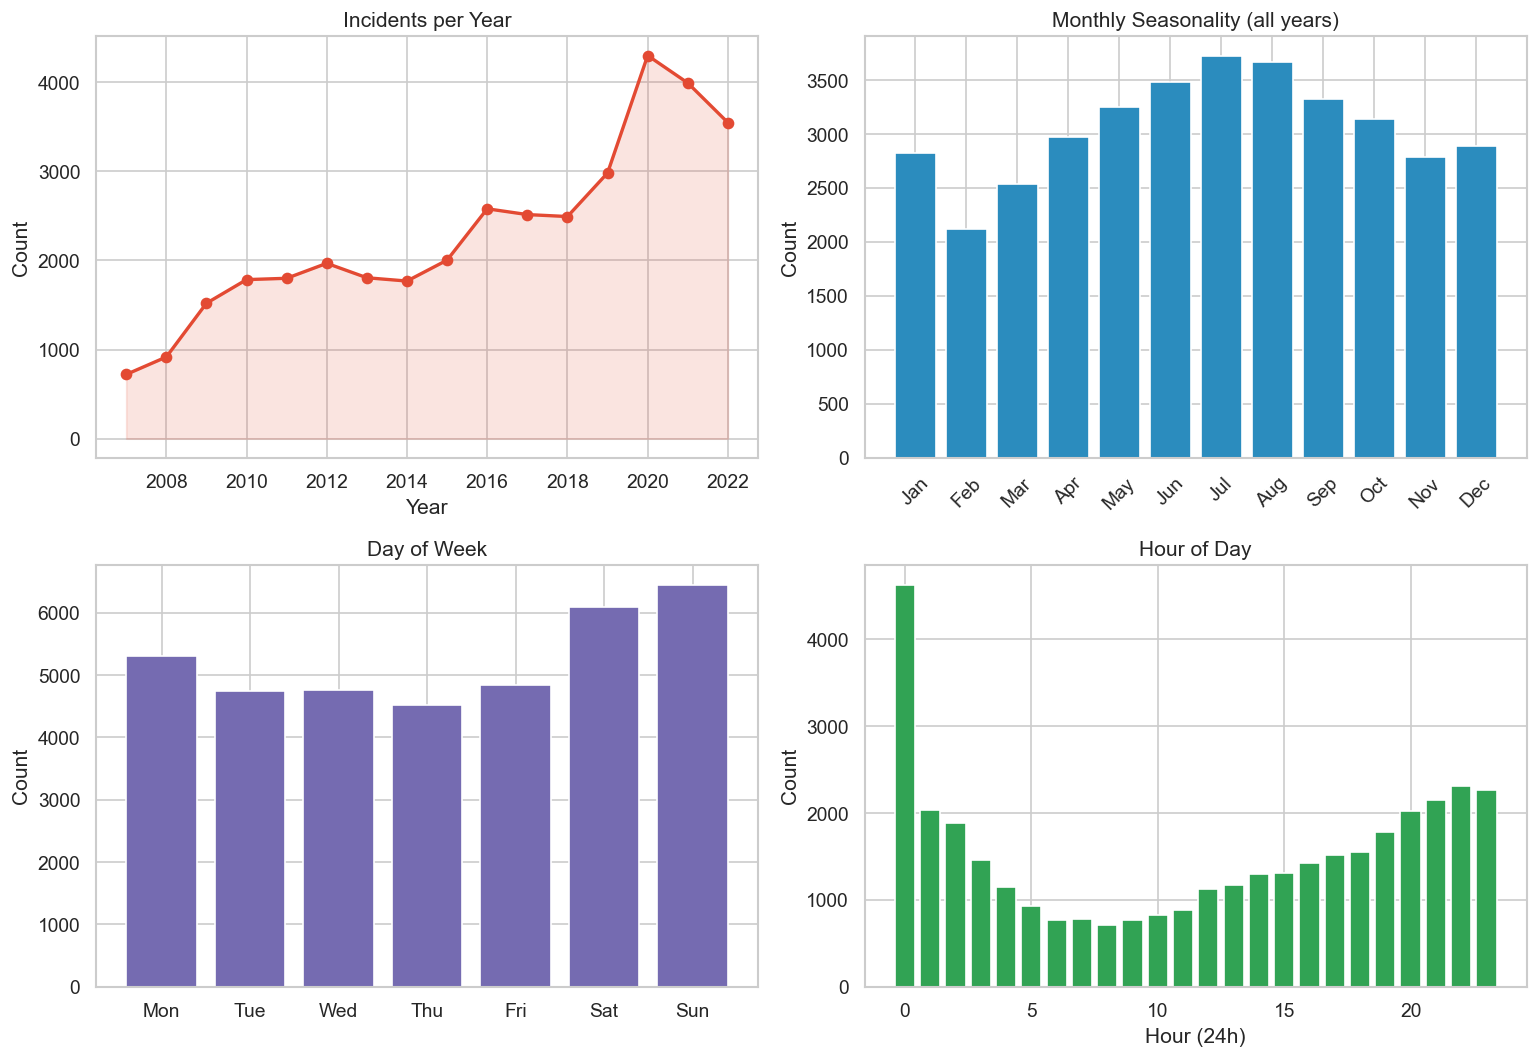

In [124]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Yearly
yearly = df.groupby('year').size()
axes[0,0].plot(yearly.index, yearly.values, 'o-', color='#e34a33', lw=2)
axes[0,0].fill_between(yearly.index, yearly.values, alpha=0.15, color='#e34a33')
axes[0,0].set_title('Incidents per Year')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Count')

# Monthly
monthly = df.groupby('month').size()
axes[0,1].bar(monthly.index, monthly.values, color='#2b8cbe', edgecolor='white')
axes[0,1].set_xticks(range(1, 13))
axes[0,1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                             'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
axes[0,1].set_title('Monthly Seasonality (all years)')
axes[0,1].set_ylabel('Count')

# Day of week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = df['dow'].value_counts().reindex(dow_order)
axes[1,0].bar(range(7), dow_counts.values, color='#756bb1', edgecolor='white')
axes[1,0].set_xticks(range(7))
axes[1,0].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[1,0].set_title('Day of Week')
axes[1,0].set_ylabel('Count')

# Hour
hour_counts = df.groupby('hour').size()
axes[1,1].bar(hour_counts.index, hour_counts.values, color='#31a354', edgecolor='white')
axes[1,1].set_title('Hour of Day')
axes[1,1].set_xlabel('Hour (24h)')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()

A few things stand out:

**Yearly trend**: There is a big spike in 2020 which likely reflects the well-documented national increase in homicides during the COVID-19 pandemic. The numbers were lower in the earlier years (2007-2009) which is partly because fewer cities were reporting to NIBRS at that time.

**Monthly seasonality**: Summer months (June through September) have noticeably higher counts than winter months. This is consistent with the general criminology finding that violent crime increases in warmer weather.

**Day of week**: Weekends, especially Saturday and Sunday, have the highest counts. This makes sense given that weekend nights tend to have more social activity and alcohol consumption.

**Hour of day**: There is a very clear nighttime peak. Incidents ramp up starting around 6-7 PM, peak between 8 PM and midnight, and then taper off through the early morning hours. The spike at hour 0 is inflated by those midnight-exact timestamps we flagged earlier.

Lets also look at how the yearly trends vary by city since they might not all follow the same pattern:

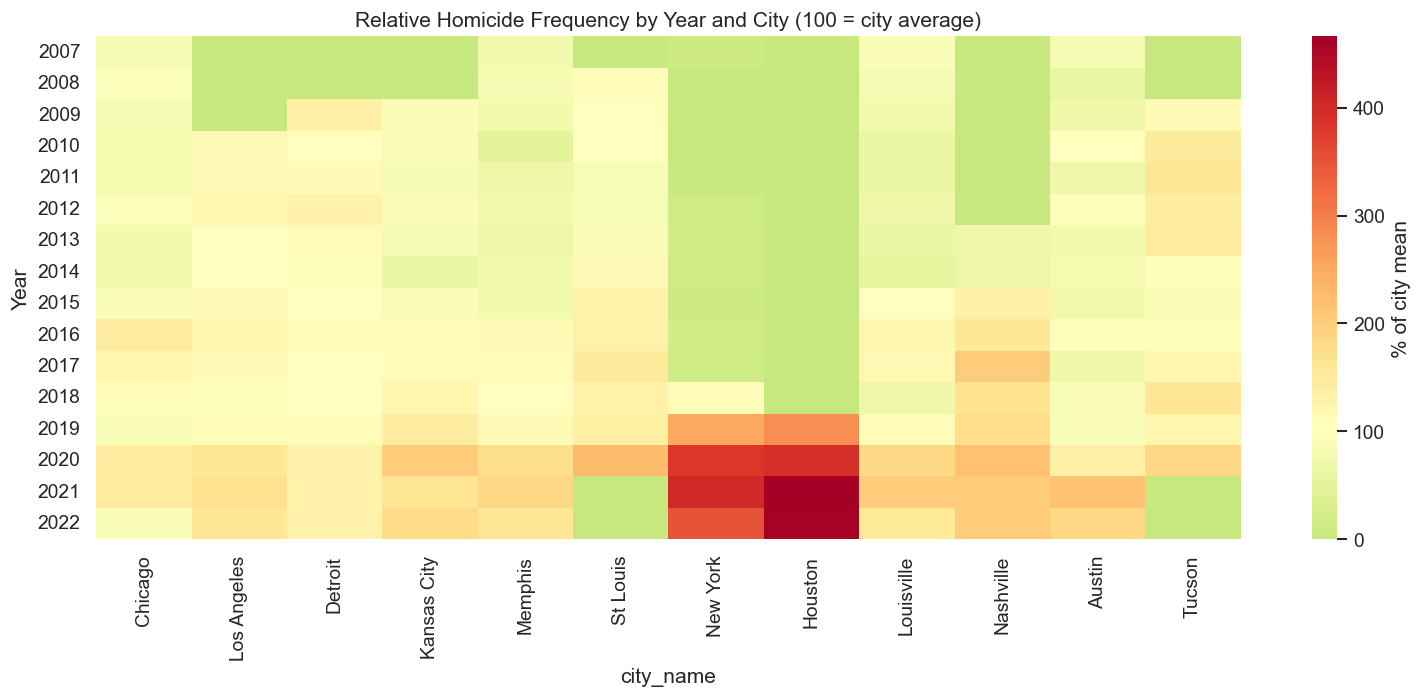

In [125]:
year_city = pd.crosstab(df['year'], df['city_name'])
# Normalize within each city to show relative change
year_city_norm = year_city.div(year_city.mean(axis=0), axis=1) * 100

top12 = city_counts.head(12).index
plt.figure(figsize=(13, 6))
sns.heatmap(year_city_norm[top12], cmap='RdYlGn_r', center=100,
            annot=False, cbar_kws={'label': '% of city mean'})
plt.title('Relative Homicide Frequency by Year and City (100 = city average)')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

This heatmap normalizes each city by its own average so we can compare relative trends. The 2020 spike shows up in almost every city (dark red). Some cities like St Louis and Memphis were already running hot before 2020. Detroit shows a gradual decline over the period while Chicago had a big jump in 2016. These city-level differences are important context — temporal patterns are not uniform across the dataset.

Another temporal feature that matters for crime linkage is the time gap between consecutive incidents within a city. If a series of linked crimes has a characteristic interval (like one every few weeks), that pattern would show up in the gap distribution.

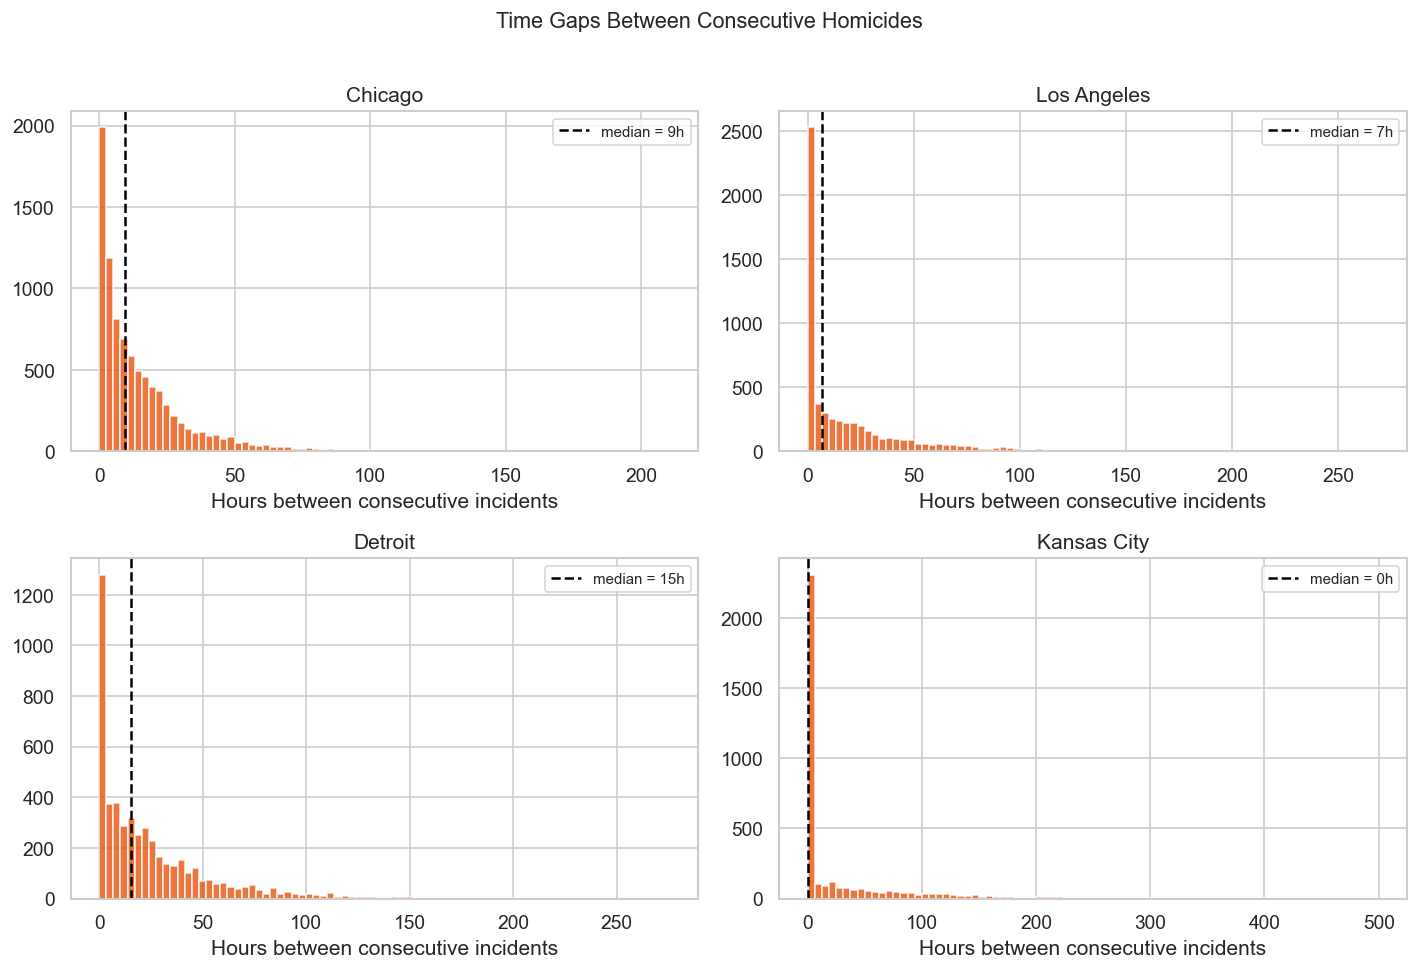

In [126]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, city in zip(axes.flat, top4):
    sub = df[df['city_name'] == city].sort_values('date_single')
    gaps = sub['date_single'].diff().dt.total_seconds() / 3600  # hours
    gaps = gaps.dropna()
    ax.hist(gaps[gaps < 500], bins=80, color='#e6550d', edgecolor='white', alpha=0.8)
    ax.axvline(gaps.median(), color='black', ls='--', lw=1.5,
               label=f'median = {gaps.median():.0f}h')
    ax.set_title(f'{city}')
    ax.set_xlabel('Hours between consecutive incidents')
    ax.legend(fontsize=9)
plt.suptitle('Time Gaps Between Consecutive Homicides', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Chicago has a median gap of around 18 hours between consecutive homicides — basically almost one a day. Kansas City and Detroit have longer gaps in the range of 30-50 hours. These gaps are for all homicides in the city, not linked series. In a real linkage scenario we would be comparing the gap between two specific incidents, so these distributions give us a sense of the background rate that linked pairs would need to stand out against.

### Location Features

The location_type and location_category columns are the closest thing we have to modus operandi (MO) features in this dataset. They tell us about the type of place where the incident occurred. Lets see what values are present and how common each one is.

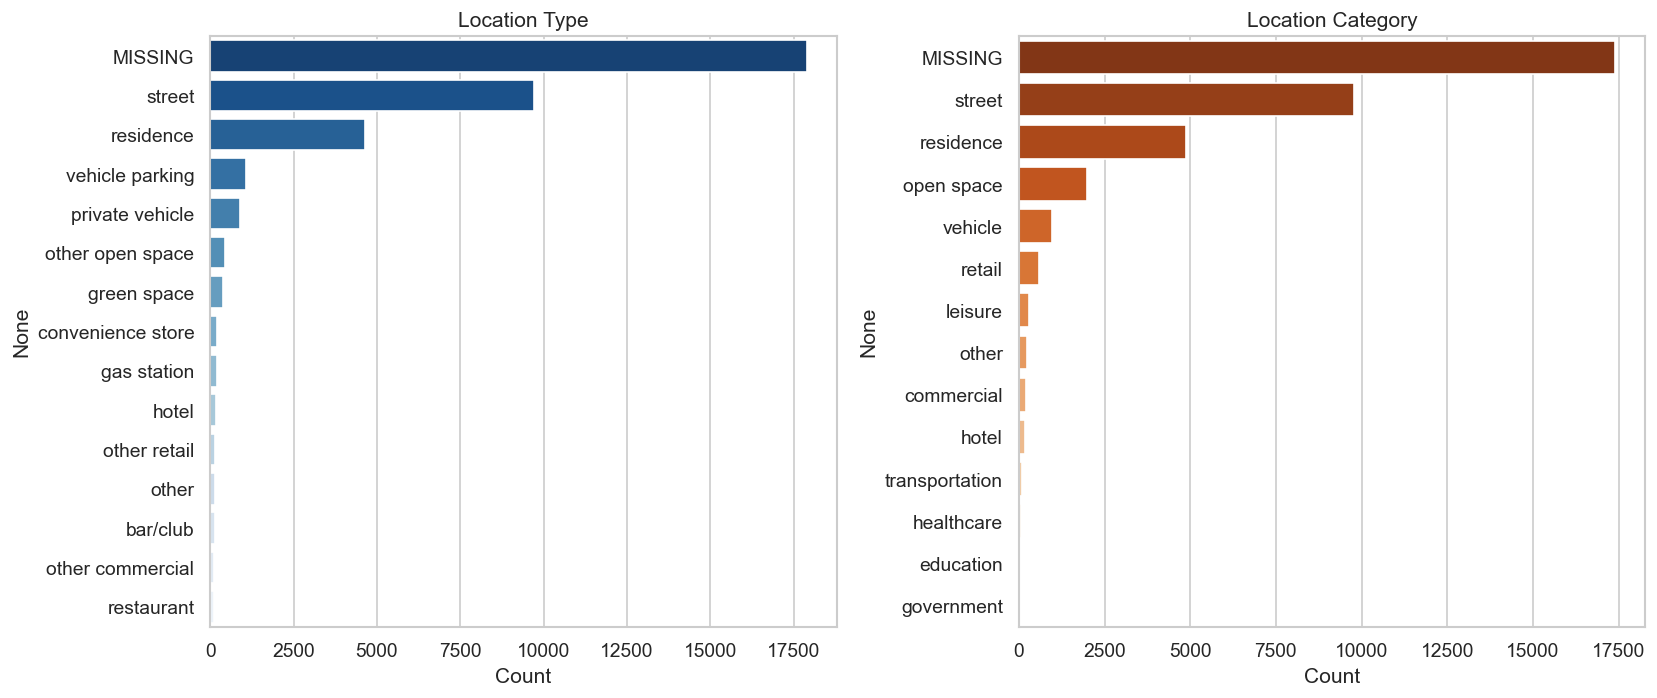

In [127]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Location type
loc_type = df['location_type'].value_counts(dropna=False).head(15)
loc_type.index = [str(x) if pd.notna(x) else 'MISSING' for x in loc_type.index]
sns.barplot(x=loc_type.values, y=loc_type.index, palette='Blues_r', ax=axes[0])
axes[0].set_title('Location Type')
axes[0].set_xlabel('Count')

# Location category
loc_cat = df['location_category'].value_counts(dropna=False).head(15)
loc_cat.index = [str(x) if pd.notna(x) else 'MISSING' for x in loc_cat.index]
sns.barplot(x=loc_cat.values, y=loc_cat.index, palette='Oranges_r', ax=axes[1])
axes[1].set_title('Location Category')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

The most common location type is street followed by residence, with missing values making up the largest single group. The location_category column is a broader grouping of the same information — street, residence, open space, vehicle, retail, etc.

The fact that street and residence account for the majority of non-missing values means this feature has limited variety for distinguishing between incidents. Still, the difference between a homicide at a bar/club versus a residence versus on the street is potentially meaningful for linkage — serial offenders often have preferred hunting grounds.

Lets look at how location type and location category relate to each other:

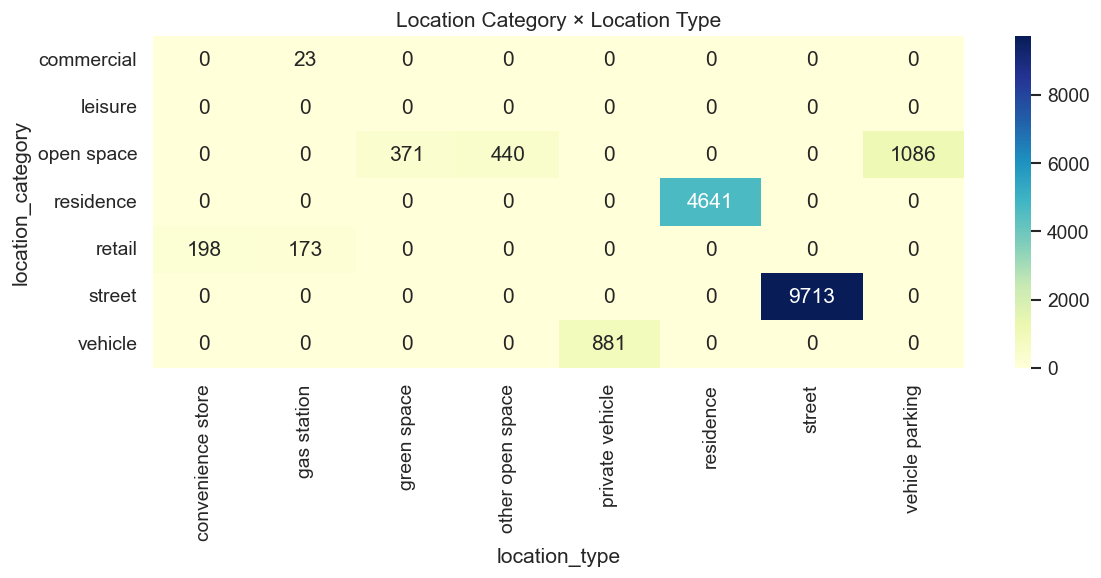

In [128]:
sub_loc = df.dropna(subset=['location_type', 'location_category'])
ct = pd.crosstab(sub_loc['location_category'], sub_loc['location_type'])

top_cats = sub_loc['location_category'].value_counts().head(7).index
top_types = sub_loc['location_type'].value_counts().head(8).index
ct_sub = ct.loc[ct.index.isin(top_cats), ct.columns.isin(top_types)]

plt.figure(figsize=(10, 5))
sns.heatmap(ct_sub, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Location Category × Location Type')
plt.tight_layout()
plt.show()

The cross-tabulation shows that location_category is mostly a roll-up of location_type. Street maps almost entirely to street, residence to residence, etc. There is some additional detail in location_type (like separating private vehicle from vehicle parking) but overall these two columns carry similar information. We probably only need one of them for our distance metric, with location_type being the more granular choice.

### Relationships Between Features

Now lets look at how different features interact. One of the most interesting cross-domain patterns is how the time of day varies by location type:

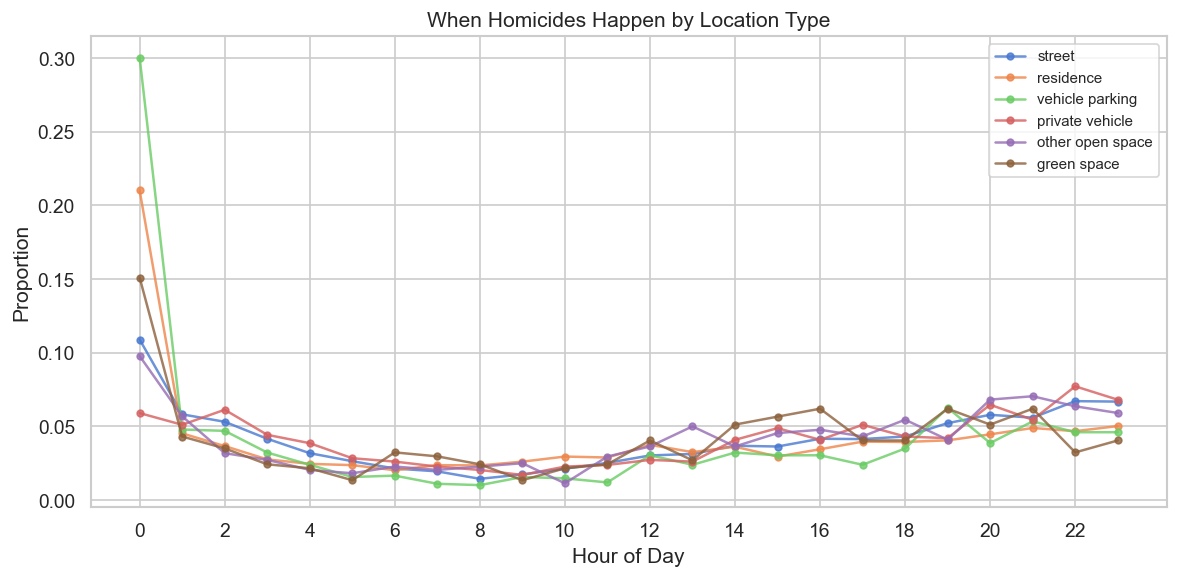

In [129]:
sub_st = df.dropna(subset=['location_type'])
top_locs = sub_st['location_type'].value_counts().head(6).index
sub_st = sub_st[sub_st['location_type'].isin(top_locs)]

plt.figure(figsize=(10, 5))
for lt in top_locs:
    grp = sub_st[sub_st['location_type'] == lt]
    hour_dist = grp['hour'].value_counts(normalize=True).sort_index()
    plt.plot(hour_dist.index, hour_dist.values, 'o-', label=lt, alpha=0.8, markersize=4)

plt.xlabel('Hour of Day')
plt.ylabel('Proportion')
plt.title('When Homicides Happen by Location Type')
plt.legend(fontsize=9)
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

 Bar/club homicides have a sharp spike in the late night and early morning hours (11 PM to 3 AM). Street homicides follow a similar nighttime pattern but are more spread out. Residence homicides are more evenly distributed throughout the day.

This means that location type and time of day are not independent. A homicide at a bar at 2 AM looks very different from a homicide at a residence at 2 PM.

Lets also check if the spatial pattern changes between weekdays and weekends. If hot spots shift on the weekend, that tells us something about the geographic structure of crime in a city:

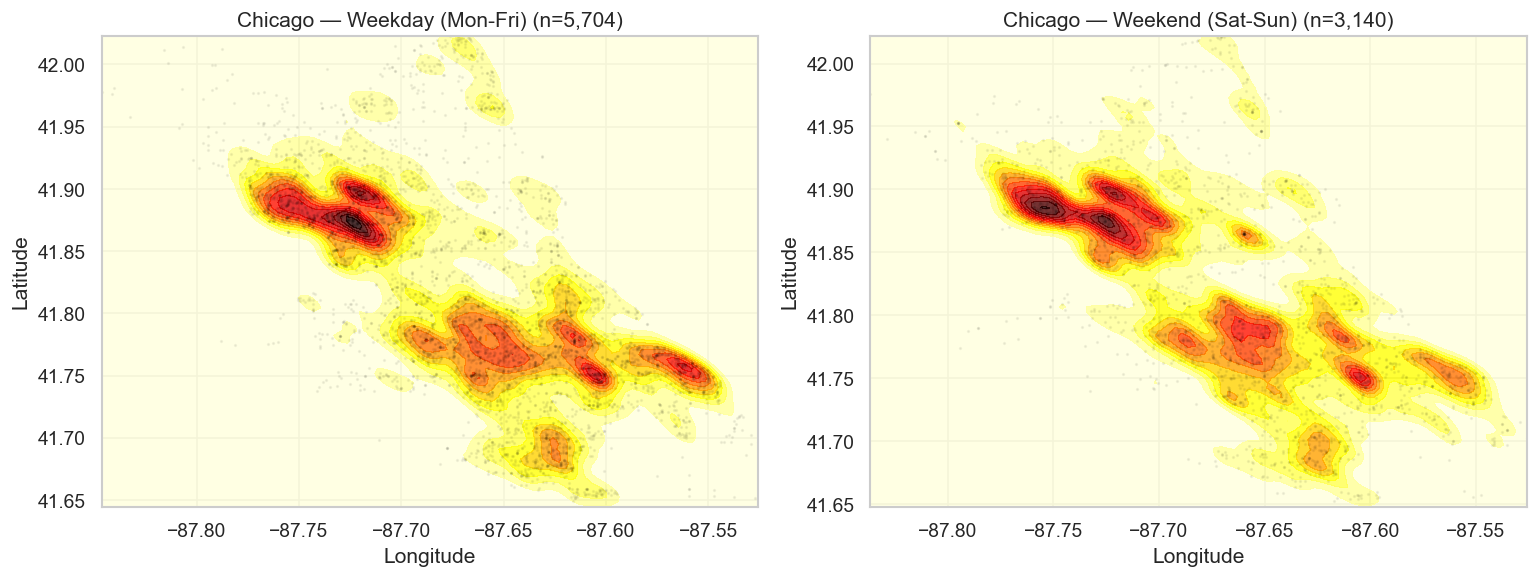

In [130]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
city_focus = 'Chicago'
sub_city = df[df['city_name'] == city_focus]

for ax, (label, mask) in zip(axes, [('Weekday (Mon-Fri)', sub_city['dow'].isin(['Monday','Tuesday','Wednesday','Thursday','Friday'])),
                                      ('Weekend (Sat-Sun)', sub_city['dow'].isin(['Saturday','Sunday']))]):
    s = sub_city[mask]
    xy = np.vstack([s['longitude'], s['latitude']])
    kde = gaussian_kde(xy, bw_method=0.1)
    xmin, xmax = s['longitude'].min(), s['longitude'].max()
    ymin, ymax = s['latitude'].min(), s['latitude'].max()
    xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=15, cmap='hot_r', alpha=0.8)
    ax.scatter(s['longitude'], s['latitude'], s=1, alpha=0.05, color='black')
    ax.set_title(f'{city_focus} — {label} (n={len(s):,})')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

The hot spot geography in Chicago is fairly stable between weekdays and weekends. The south and west sides consistently show the highest density. This spatial consistency at the aggregate level is actually a useful property — it means the background spatial distribution is relatively stationary, which makes it easier to identify anomalous spatial clusters that might represent linked series.

Looking at the numeric columns to see if there are any obvious correlations:

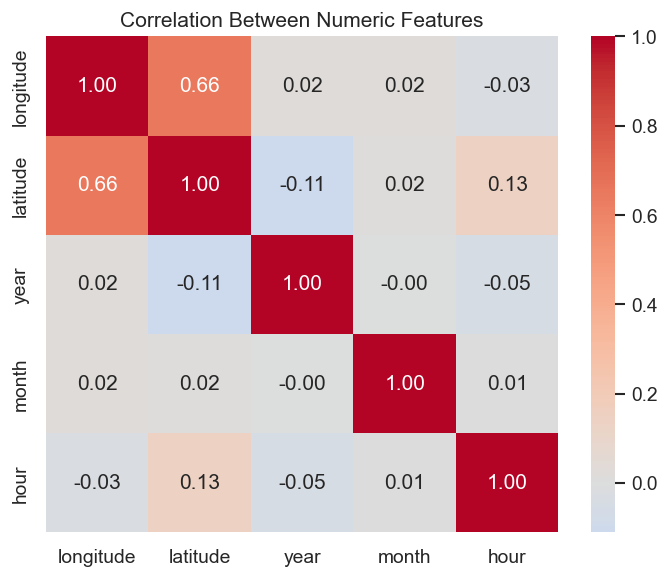

In [131]:
numeric_cols = df[['longitude', 'latitude', 'year', 'month', 'hour']].copy()
plt.figure(figsize=(6, 5))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Between Numeric Features')
plt.tight_layout()
plt.show()

As expected there is not much correlation between these features. Longitude and latitude have a slight positive correlation which just reflects the geographic clustering of our cities (northeast cities tend to have both higher latitudes and less negative longitudes). The year column has essentially no correlation with anything else which is fine — it just means the time and space distributions are stable over the dataset period.

The lack of strong correlations between the numeric features is actually a good sign for our model — it means each feature block carries somewhat independent information, which is what we want in a composite metric.

One more relationship to look at — do different cities have different location type profiles? If a city has mostly street homicides while another has mostly residential ones, that affects how useful this feature is for within-city linkage:

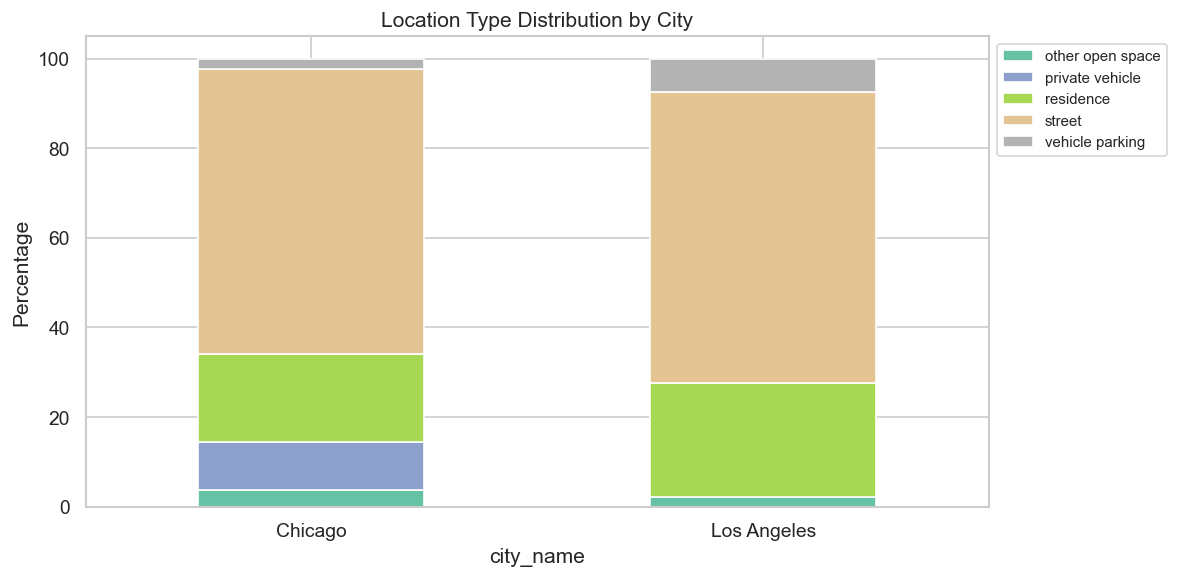

In [132]:
top5 = df['city_name'].value_counts().head(6).index
top_types_list = df['location_type'].value_counts().head(5).index.tolist()
sub = df[df['city_name'].isin(top5) & df['location_type'].isin(top_types_list)]
ct_city = pd.crosstab(sub['city_name'], sub['location_type'], normalize='index') * 100

ct_city.plot.bar(stacked=True, figsize=(10, 5), colormap='Set2', edgecolor='white')
plt.ylabel('Percentage')
plt.title('Location Type Distribution by City')
plt.legend(fontsize=9, bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The proportions vary by city. Kansas City has a higher share of incidents in vehicles and open spaces compared to the others. Austin has a higher proportion of residential incidents. These city-level differences mean that a location type that is unusual in one city might be common in another. This is worth keeping in mind when we build the categorical distance — ideally it should reflect how unusual a location type is within its local context, not just globally.

## Whats Missing?

This is just as important as what the data contains. Looking at what our model needs versus what CODE provides:

**Available in CODE:**
- Geographic coordinates (longitude, latitude) — complete
- Timestamps (date_single) — complete, with some quality concerns around midnight-exact values
- Location type and category — available but ~49% missing, city-dependent
- Census block identifiers — complete

**Not available in CODE:**
- **Weapon type** — this is a key MO feature for crime linkage but is not in this dataset
- **Victim demographics** (age, sex, race) — essential for the victim dissimilarity block
- **Cause of death / manner** — important for behavioral similarity
- **Crime scene details** (disposal type, overkill indicators, posing) — highly relevant for serial crime linkage but requires detailed case-level data

The Murder Accountability Project (MAP) dataset which we have separately does include weapon type and basic victim demographics. Integrating that data will be a necessary next step to fill these gaps before building the full model.

## Looping to Proposal and Next Steps

Now that we have explored the data and understand what is in it, whats missing, and how the features relate to each other, its a good time to bring in the framework from our research proposal to see how these findings map onto the model we plan to build.

The core of our model is a composite distance metric that measures how similar two homicide incidents are across four feature blocks:

$$d(x_i, x_j) = w_s \tilde{d}_s + w_t \tilde{d}_t + w_c d_c + w_v \tilde{d}_v$$

Where:
- $d_s$ = spatial distance (Haversine distance between coordinates)
- $d_t$ = temporal distance (time interval between incidents)
- $d_c$ = categorical dissimilarity (how different the crime scene characteristics are)
- $d_v$ = victim feature dissimilarity (how different the victim profiles are)
- The $w$ values are weights that control how much each block contributes

The idea is that if two incidents are close in space, close in time, carried out in a similar way, and target similar victims, they are more likely to be linked. Each of the four terms captures one of those dimensions.

Lets walk through each block and connect it to what we found in the EDA.

### Spatial Block ($d_s$)

This is our strongest block in terms of data availability. Every incident has complete longitude and latitude so we can compute Haversine distances for all 36,699 records with no missing values.

From the EDA we saw that within-city spatial distributions are right-skewed — most incident pairs within a city are relatively close together with a long tail of farther-apart pairs. We also saw that city footprints vary significantly (LA is much more spread out than Detroit for example). This means raw Haversine distances are not directly comparable across cities.

Our plan from the proposal is to handle this with **log-transformation followed by rank normalization**. Lets take a quick look at what that would actually do to the distance distributions:

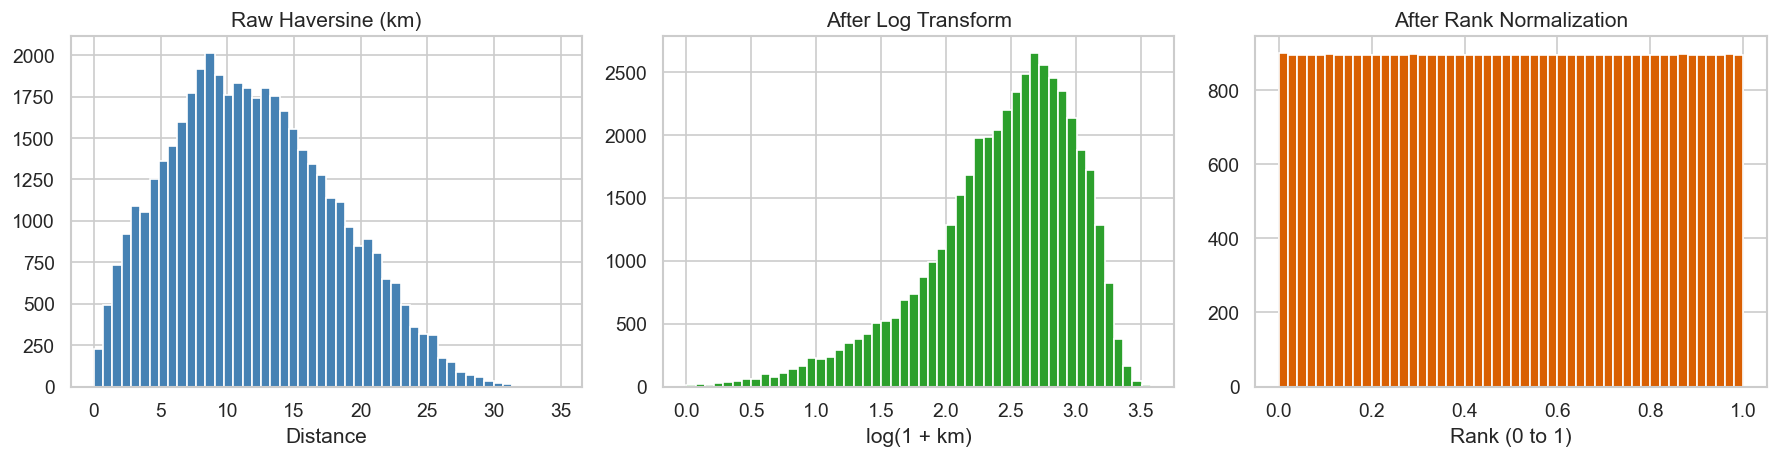

Raw — median: 11.6 km, mean: 12.0 km
Rank normalized values range from 0.0001 to 1.0000


In [133]:
# Demonstrating the normalization pipeline on spatial distances
from scipy.stats import rankdata

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

# Sample from Memphis as a mid-size city
sample_city = df[df['city_name'] == 'Memphis'].sample(300, random_state=42)
coords = sample_city[['latitude', 'longitude']].values

spatial_dists = []
for i in range(len(coords)):
    for j in range(i+1, len(coords)):
        spatial_dists.append(haversine_km(coords[i,0], coords[i,1], coords[j,0], coords[j,1]))
spatial_dists = np.array(spatial_dists)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(spatial_dists, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Raw Haversine (km)')
axes[0].set_xlabel('Distance')

axes[1].hist(np.log1p(spatial_dists), bins=50, color='#2ca02c', edgecolor='white')
axes[1].set_title('After Log Transform')
axes[1].set_xlabel('log(1 + km)')

spatial_ranks = rankdata(spatial_dists) / len(spatial_dists)
axes[2].hist(spatial_ranks, bins=50, color='#d95f02', edgecolor='white')
axes[2].set_title('After Rank Normalization')
axes[2].set_xlabel('Rank (0 to 1)')

plt.tight_layout()
plt.show()

print(f'Raw — median: {np.median(spatial_dists):.1f} km, mean: {np.mean(spatial_dists):.1f} km')
print(f'Rank normalized values range from {spatial_ranks.min():.4f} to {spatial_ranks.max():.4f}')

The raw distances are heavily right-skewed. The log transform helps spread things out but still leaves some skew. Rank normalization forces the distribution to be uniform between 0 and 1, which is exactly what we want — it means that no matter the original scale of the distances, the spatial block will contribute values between 0 and 1 to the composite metric. Two incidents that are relatively close (compared to other pairs) will get a low rank value, and two that are far apart will get a high one.

### Temporal Block ($d_t$)

The temporal block also has strong data coverage since date_single is populated for every record. We saw clear patterns in the EDA — summer peaks, weekend concentration, nighttime clustering. These patterns describe the overall background distribution but for linkage what matters is the absolute time gap between two specific incidents.

Lets look at what the pairwise temporal distance distribution looks like and how it responds to the same normalization:

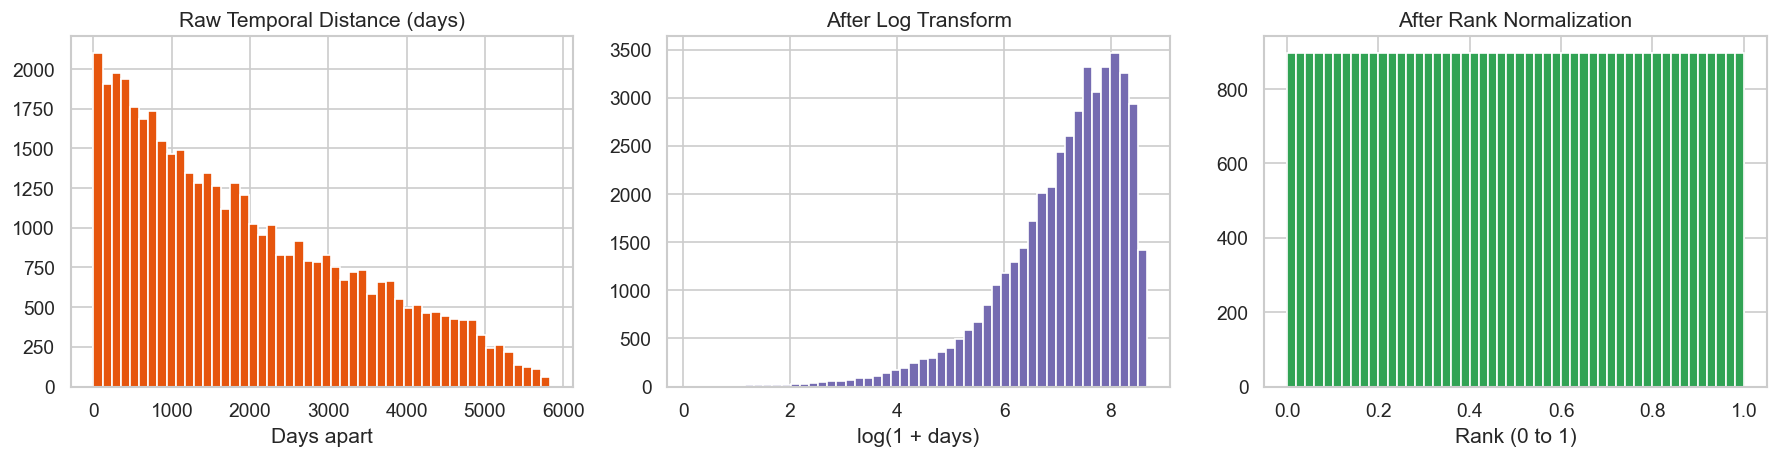

Raw — median: 1595 days, mean: 1910 days
Max gap: 5834 days (16.0 years)


In [134]:
# Pairwise temporal distances from the same Memphis sample
dates = sample_city['date_single'].values
temporal_dists = []
for i in range(len(dates)):
    for j in range(i+1, len(dates)):
        temporal_dists.append(abs((dates[i] - dates[j]) / np.timedelta64(1, 'D')))
temporal_dists = np.array(temporal_dists)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(temporal_dists, bins=50, color='#e6550d', edgecolor='white')
axes[0].set_title('Raw Temporal Distance (days)')
axes[0].set_xlabel('Days apart')

axes[1].hist(np.log1p(temporal_dists), bins=50, color='#756bb1', edgecolor='white')
axes[1].set_title('After Log Transform')
axes[1].set_xlabel('log(1 + days)')

temporal_ranks = rankdata(temporal_dists) / len(temporal_dists)
axes[2].hist(temporal_ranks, bins=50, color='#31a354', edgecolor='white')
axes[2].set_title('After Rank Normalization')
axes[2].set_xlabel('Rank (0 to 1)')

plt.tight_layout()
plt.show()

print(f'Raw — median: {np.median(temporal_dists):.0f} days, mean: {np.mean(temporal_dists):.0f} days')
print(f'Max gap: {np.max(temporal_dists):.0f} days ({np.max(temporal_dists)/365:.1f} years)')

Same story as spatial — very right-skewed in raw form. Pairs of incidents from the same sample span anywhere from same-day to over a decade apart. Rank normalization brings everything onto the same 0 to 1 scale. After normalization, the spatial and temporal blocks are directly comparable which is critical since the composite metric adds them together with weights.

### Categorical Block ($d_c$)

This is where things get more challenging. The categorical block is meant to capture how similar the *method* or *setting* of two incidents is, things like weapon type, location type, and cause of death. In our proposal this uses Hamming or Jaccard distance across categorical features.

From the EDA we know that the only categorical features available in CODE are location_type and location_category, and these are about 49% missing. We also saw that location_category is mostly just a roll-up of location_type, so we really only have one usable categorical feature.

Lets see what the effective discriminative power of location_type looks like:

Unique location types (non-missing): 33
Top 3 types account for 82.1% of non-missing records

Records with location_type: 18,804 (51.2%)
Records missing location_type: 17,895 (48.8%)


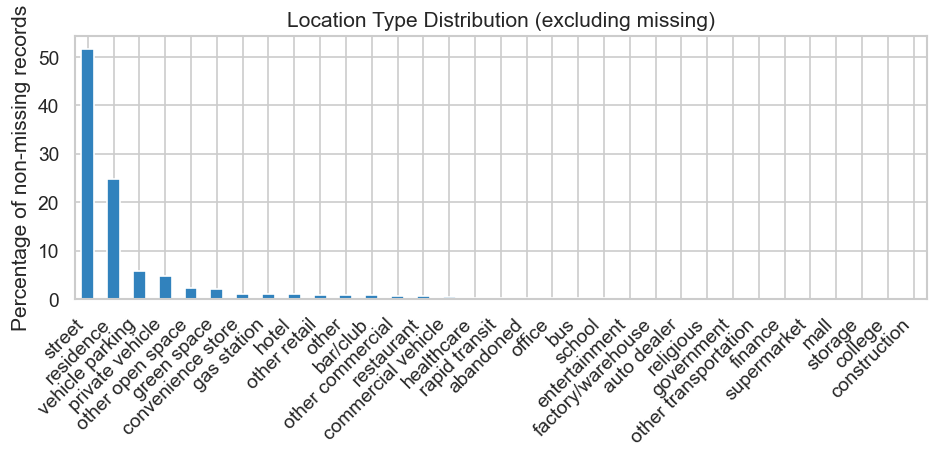

In [135]:
# How many unique values and how concentrated is the distribution
loc_counts = df['location_type'].value_counts(dropna=True)
print(f'Unique location types (non-missing): {len(loc_counts)}')
print(f'Top 3 types account for {loc_counts.head(3).sum() / loc_counts.sum() * 100:.1f}% of non-missing records')
print(f'\nRecords with location_type: {df["location_type"].notna().sum():,} ({df["location_type"].notna().mean()*100:.1f}%)')
print(f'Records missing location_type: {df["location_type"].isna().sum():,} ({df["location_type"].isna().mean()*100:.1f}%)')

fig, ax = plt.subplots(figsize=(8, 4))
(loc_counts / loc_counts.sum() * 100).plot.bar(ax=ax, color='#3182bd', edgecolor='white')
ax.set_ylabel('Percentage of non-missing records')
ax.set_title('Location Type Distribution (excluding missing)')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Street and residence alone make up a large majority of the non-missing records. So even when location_type *is* reported, most incidents fall into just two buckets. That limits how much this feature can help distinguish between incidents — if both crimes happened on a street, that tells us very little since most crimes happen on a street.

The real MO features we want (weapon type, cause of death, disposal method) are not available here. The MAP dataset has weapon type which would add a lot more discriminative value to this block.

### Victim Block ($d_v$)

As we covered in the "What the Data Does Not Have" section, CODE contains no victim-level features at all. This means the $d_v$ block is completely empty with this dataset. In the composite metric this would mean setting $w_v = 0$ and relying entirely on the other three blocks.

The MAP/SHR data has victim age, sex, race, and offender-victim relationship. Integrating that data would activate this block. For now the model would effectively be:

$$d(x_i, x_j) = w_s \tilde{d}_s + w_t \tilde{d}_t + w_c d_c$$

with a weakened $d_c$ due to limited categorical features.

## Addressing Flagged Findings

Throughout the EDA we identified several data quality issues and structural concerns. Lets consolidate them and think about potential fixes for each one.

### 1. Midnight-Exact Timestamps

We found that 7.2% of records (about 2,640 incidents) have timestamps of exactly 00:00. These likely represent cases where the actual time of the incident was unknown and got recorded as a default value.

In [136]:
midnight = (df['date_single'].dt.hour == 0) & (df['date_single'].dt.minute == 0)

# How does this vary by city?
midnight_by_city = df.groupby('city_name').apply(
    lambda g: ((g['date_single'].dt.hour == 0) & (g['date_single'].dt.minute == 0)).mean() * 100
).sort_values(ascending=False).round(1)

print('Midnight-exact timestamps by city (%):')
print(midnight_by_city.to_string())

Midnight-exact timestamps by city (%):
city_name
Houston             100.0
Mesa                100.0
Fort Worth           92.2
Charlotte            91.2
Detroit               3.8
Boston                2.7
Memphis               2.4
Virginia Beach        1.9
Colorado Springs      1.0
Nashville             1.0
Austin                0.6
Louisville            0.6
Tucson                0.4
Chicago               0.3
Kansas City           0.1
New York              0.1
Los Angeles           0.0
Minneapolis           0.0
San Francisco         0.0
St Louis              0.0


**Potential fix:** We should create a boolean flag column (something like `time_imputed`) that marks these records. When computing temporal distances, pairs where one or both incidents have this flag should carry reduced confidence. One approach is to keep the temporal distance calculation as-is but attach a metadata flag that the weighting step can use — for example downweighting $d_t$ for those pairs, or widening the uncertainty around the temporal distance. This keeps the distance computation clean and pushes the missingness handling into a separate metadata layer.

### 2. City-Dependent Location Missingness

Almost half the records are missing location_type, and this is almost entirely driven by which city the record comes from. Some cities report it nearly 100% of the time while others report it almost never.

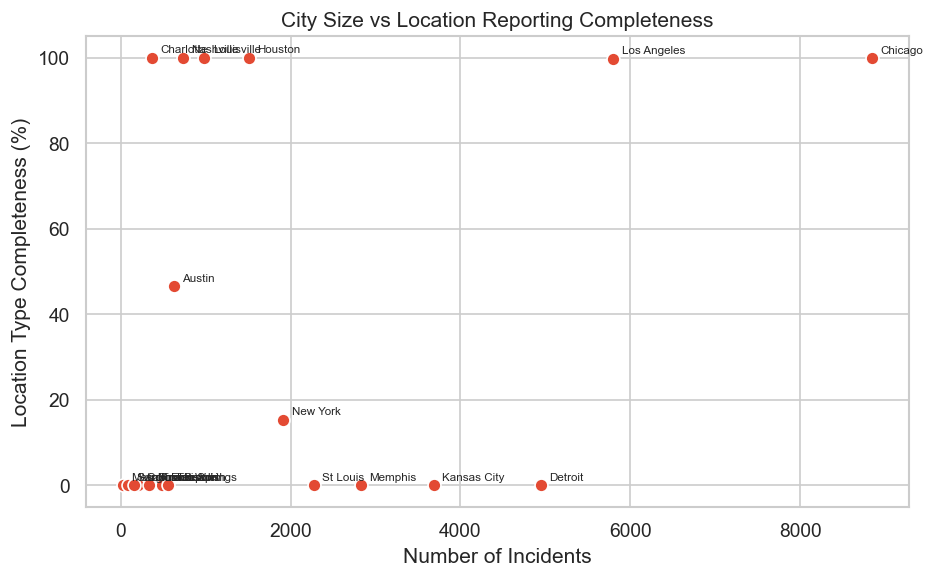

In [137]:
# Visualize the relationship between city size and location completeness
city_info = df.groupby('city_name').agg(
    n=('uid', 'count'),
    loc_complete=('location_type', lambda x: x.notna().mean() * 100)
).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(city_info['n'], city_info['loc_complete'], s=60, color='#e34a33', edgecolor='white')
for city, row in city_info.iterrows():
    ax.annotate(city, (row['n'], row['loc_complete']), fontsize=7, ha='left',
                xytext=(5, 3), textcoords='offset points')
ax.set_xlabel('Number of Incidents')
ax.set_ylabel('Location Type Completeness (%)')
ax.set_title('City Size vs Location Reporting Completeness')
plt.tight_layout()
plt.show()

There is no strong relationship between city size and reporting completeness — its simply a matter of what each department chooses to publish. Chicago is huge but reports almost no location data, while much smaller cities like Austin and Virginia Beach report it fully.

**Potential fix:** For the categorical distance block, when comparing two incidents and one or both are missing location_type, we have a few options:
- **Exclude the feature from that pair's $d_c$** and renormalize the remaining features (if we had more categorical features this would work better, but with only one feature this means $d_c$ becomes undefined)
- **Assign a neutral distance** like 0.5 (the midpoint of the 0 to 1 range) so that missing pairs dont artificially look similar or dissimilar
- **Downweight $w_c$** for those pairs via a missingness multiplier

The neutral distance approach is probably the most practical for now since it avoids introducing bias in either direction. But really the better long-term fix is to supplement with data that has more complete categorical features like the MAP weapon field.

### 3. City Imbalance

Chicago makes up about 24% of the dataset. If we compute pairwise distances across the whole dataset, Chicago-Chicago pairs will dominate the distance matrix.

In [138]:
# How much would Chicago dominate pairwise comparisons?
city_n = df['city_name'].value_counts()
total_pairs = len(df) * (len(df) - 1) / 2

chicago_n = city_n['Chicago']
chicago_pairs = chicago_n * (chicago_n - 1) / 2

print(f'Total possible pairs: {total_pairs:,.0f}')
print(f'Chicago-Chicago pairs: {chicago_pairs:,.0f} ({chicago_pairs/total_pairs*100:.1f}%)')

print('\nTop 3 cities combined:')
top3_pairs = sum(city_n.head(3).apply(lambda n: n*(n-1)/2))
print(f'  Within-city pairs: {top3_pairs:,.0f} ({top3_pairs/total_pairs*100:.1f}%)')

Total possible pairs: 673,389,951
Chicago-Chicago pairs: 39,103,746 (5.8%)

Top 3 cities combined:
  Within-city pairs: 68,158,024 (10.1%)


**Potential fix:** During weight calibration we could use **stratified sampling** to balance representation across cities. For example drawing an equal number of incident pairs from each city (or weighting the loss function inversely by city frequency). This ensures the learned weights reflect patterns across all cities, not just the largest ones. For the actual clustering step we would still use all the data.

### 4. Limited Temporal Windows

Most incidents only have a single timestamp (date_single). The date_start and date_end fields which could represent an uncertainty window around when the crime actually happened are only available for about 17% of records.

In [139]:
has_window = df['date_start'].notna() & df['date_end'].notna()
has_start_only = df['date_start'].notna() & df['date_end'].isna()

print(f'Has full window (start + end): {has_window.sum():,} ({has_window.mean()*100:.1f}%)')
print(f'Has start only: {has_start_only.sum():,}')
print(f'Has date_single only: {(~df["date_start"].notna()).sum():,} ({(~df["date_start"].notna()).mean()*100:.1f}%)')

# For those with windows, how wide are they?
window_hours = (df.loc[has_window, 'date_end'] - df.loc[has_window, 'date_start']).dt.total_seconds() / 3600
print(f'\nFor records with windows:')
print(f'  Median window: {window_hours.median():.1f} hours')
print(f'  Mean window: {window_hours.mean():.1f} hours')
print(f'  Max window: {window_hours.max():.1f} hours ({window_hours.max()/24:.0f} days)')

Has full window (start + end): 4,396 (12.0%)
Has start only: 1,784
Has date_single only: 30,519 (83.2%)

For records with windows:
  Median window: 0.0 hours
  Mean window: 15.4 hours
  Max window: 52584.5 hours (2191 days)


**Potential fix:** Since 83% of records only have date_single, we should use that as the primary temporal reference for all records. The date_start/date_end windows can optionally be used as uncertainty metadata — for example when computing the temporal distance between two incidents, if one has a window we could use the closest edge of the window rather than just the midpoint. But this is a refinement, not a necessity for the initial model. For the first pass, date_single is sufficient.

### 5. Missing Feature Blocks

The most significant limitation is the absence of weapon type and victim-level data. Without these, two of the four feature blocks in our composite metric are either empty ($d_v$) or severely weakened ($d_c$ with only location type).

**Potential fix:** The Murder Accountability Project (MAP) dataset has weapon type, victim age, victim sex, victim race, and offender-victim relationship. The challenge is that MAP uses county-level geography rather than coordinates and covers 1980–2014, while CODE has exact lat/lon through 2022. A potential integration strategy:
- Match incidents between CODE and MAP by city, date, and offense type where they overlap in time
- Use MAP features to fill in the categorical and victim blocks for matched records
- For unmatched records or years outside MAP coverage, fall back to the three-block model

Alternatively, we could build and validate the model on MAP data (which has the richer features) and use CODE data for the spatial precision it provides. This is something we will need to think through carefully in the next phase.

## Summary

This dataset gives us a solid foundation for the spatial and temporal components of our crime linkage model with over 36,000 geocoded and timestamped homicide incidents across 20 major US cities from 2007 to 2022.

Key takeaways from the exploration:
- The spatial coordinates are complete and show clear city-level clustering with varying footprint sizes across cities
- The temporal data reveals strong patterns — summer peaks, weekend concentration, nighttime clustering — that are consistent with known criminological findings
- The only MO-type features available (location_type/category) are about half missing and this missingness is heavily city-dependent
- There are no victim-level features, meaning we cannot compute victim dissimilarity from this dataset alone
- The 2020 COVID-era spike in homicides is visible across nearly all cities and should be accounted for
- Chicago makes up 24% of the data which creates an imbalance worth considering during model training

Next steps from here will be to integrate MAP/SHR data for the victim and weapon features, build out the pairwise distance computations, and start on the similarity metric calibration.